### Prof. Alfio Ferrara

# Codificare l'informazione

##  Metodologie informatiche nelle discipline umanistiche
##### A.A. 2026/2027


In [11]:
%load_ext autoreload
%autoreload 2

## Il linguaggio segreto

Formate gruppi di tre. In ogni gruppo:

- una persona è l'**agente segreto**: deve comunicare in quale delle seguenti nazioni si trova, usando solo delle carte da gioco mostrate una alla volta — **Italia, Francia, Russia, Cina, Brasile, Egitto**;
- una persona è il **complice**: riceve le carte e ha davanti un foglio con le regole di decodifica concordate in anticipo con l'agente;
- una persona è l'**agente avversario**: riceve la stessa sequenza di carte del complice, ma non conosce le regole di decodifica.

Prima di iniziare, l'agente e il complice si accordano in segreto su un codice: una corrispondenza tra sequenze di carte e nazioni. L'obiettivo dell'agente è comunicare la nazione corretta al complice usando **il minor numero di carte possibile** — senza che l'avversario riesca a capire di quale nazione si tratti.

Provate prima usando come simboli i 4 semi delle carte (cuori, quadri, fiori, picche). Poi ripetete usando solo il colore della carta (rosso o nero).

## Un momento di riflessione

- Quante carte vi sono servite nella prima prova (4 semi)? E nella seconda (2 colori)?
- L'agente avversario è riuscito a capire la nazione, pur avendo ricevuto la stessa identica sequenza di carte del complice? Perché sì o perché no?
- Cosa vi dice questo sul rapporto tra "ricevere un messaggio" e "capire un messaggio"?
- Perché con un alfabeto più piccolo servono più carte per comunicare lo stesso numero di messaggi?
- Avanzavano combinazioni non usate, in una delle due prove (o in entrambe)? Quante?

## Verifichiamo con il calcolo

Proviamo a calcolare, per ciascun alfabeto, quante carte servono davvero per 6 messaggi, e quante combinazioni restano inutilizzate.

In [12]:
from nlp.coding import minimum_code_length, num_possible_codes

num_messages = 6

for alphabet_size, label in [(4, "4 semi"), (2, "2 colori")]:
    length = minimum_code_length(alphabet_size, num_messages)
    combinations = num_possible_codes(alphabet_size, length)
    print(f"Alfabeto: {label} ({alphabet_size} simboli)")
    print(f"  Lunghezza minima del codice: {length} carte")
    print(f"  Combinazioni disponibili: {combinations}")
    print(f"  Combinazioni inutilizzate: {combinations - num_messages}")
    print()

print("Cosa succede se proviamo con una carta in meno del necessario (2 colori, 2 carte)?")
print(f"  Combinazioni disponibili: {num_possible_codes(2, 2)} per {num_messages} messaggi -> non bastano!")

Alfabeto: 4 semi (4 simboli)
  Lunghezza minima del codice: 2 carte
  Combinazioni disponibili: 16
  Combinazioni inutilizzate: 10

Alfabeto: 2 colori (2 simboli)
  Lunghezza minima del codice: 3 carte
  Combinazioni disponibili: 8
  Combinazioni inutilizzate: 2

Cosa succede se proviamo con una carta in meno del necessario (2 colori, 2 carte)?
  Combinazioni disponibili: 4 per 6 messaggi -> non bastano!


## Dal caso concreto alla formula generale

La lunghezza minima di un codice, dato un alfabeto di B simboli e un insieme di N messaggi possibili da distinguere, è:

$$L = \lceil \log_B(N) \rceil$$

- Cosa succede a L se B aumenta? E se diminuisce?
- Perché serve l'arrotondamento all'intero superiore (⌈ ⌉)?
- Che relazione c'è tra questa formula e quella dell'entropia vista nel notebook precedente, $H = \log_2(N)$? (Suggerimento: cosa succede se B = 2?)

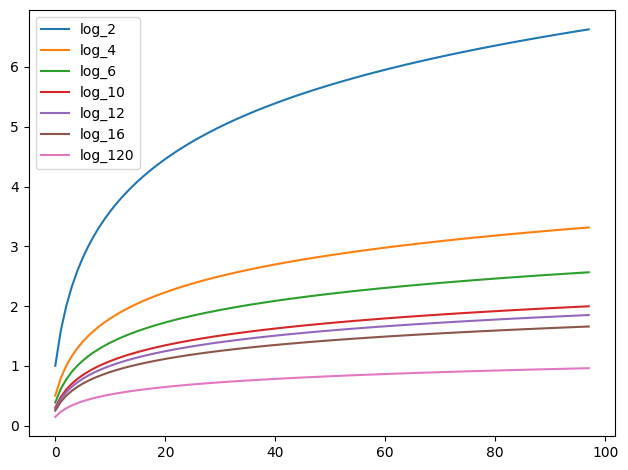

In [13]:
import numpy as np
from matplotlib import pyplot as plt
import math

series = np.array(range(2, 100))
bases = [2, 4, 6, 10, 12, 16, 120]

fig, ax = plt.subplots()
for b in bases:
    ax.plot([math.log(x, b) for x in series], label=f"log_{b}")
ax.legend()
plt.tight_layout()
plt.show()

## La codifica del testo

Nel gioco delle carte, mettervi d'accordo su un codice per 6 messaggi era già impegnativo. Per un intero alfabeto — 26 lettere, maiuscole, punteggiatura, accenti — inventare un codice condiviso al momento non è più praticabile: serve una convenzione **standardizzata**, decisa una volta per tutte e condivisa da tutti.

Un esempio storico di questo tipo di convenzione è il **codice Morse**, che dagli anni '30 dell'Ottocento associa a ogni lettera una sequenza di segnali brevi e lunghi (punti e linee). Una curiosità: le lettere più frequenti in inglese, come "e" e "t", hanno le sequenze più corte.

Il sistema che usiamo oggi per rappresentare il testo nei computer si chiama **ASCII**: ogni carattere è associato, per convenzione, a una sequenza di bit (che possiamo anche leggere come un numero, ma è la sequenza di bit quella che il computer usa e memorizza davvero). Proviamo a vedere a quali sequenze corrispondono le lettere di una parola, e a ricostruire la parola a partire da quelle sequenze.

In [14]:
word = "casa"

for character in word:
    code = ord(character)
    print(f"{character} -> {code:08b} (decimale: {code})")

encoded = [format(ord(character), "08b") for character in word]
decoded = "".join(chr(int(bits, 2)) for bits in encoded)
print(f"\nCodificata (bit): {encoded}")
print(f"Decodificata: {decoded}")

c -> 01100011 (decimale: 99)
a -> 01100001 (decimale: 97)
s -> 01110011 (decimale: 115)
a -> 01100001 (decimale: 97)

Codificata (bit): ['01100011', '01100001', '01110011', '01100001']
Decodificata: casa


ASCII, però, nacque per l'inglese e copre solo 128 caratteri: niente accenti, niente lettere di altri alfabeti. Nel tempo sono nate altre convenzioni (come Latin-1 e UTF-8) che coprono un insieme di caratteri più ampio — e che condividono con ASCII gli stessi codici per le lettere di base, ma non sempre per gli altri caratteri.

Proviamo a codificare una parola con un accento usando convenzioni diverse.

In [15]:
text = "città"

for encoding in ("ascii", "latin-1", "utf-8"):
    try:
        encoded_bytes = text.encode(encoding)
        bits = " ".join(f"{byte:08b}" for byte in encoded_bytes)
        print(f"{encoding}: {len(encoded_bytes)} byte -> {bits}")
    except UnicodeEncodeError as error:
        print(f"{encoding} -> errore: {error}")

print()
utf8_bytes = text.encode("utf-8")
print(f"Byte UTF-8 di \"{text}\": {len(utf8_bytes)} byte")
print(f"Se li decodifichiamo come Latin-1 per errore: \"{utf8_bytes.decode('latin-1')}\"")

ascii -> errore: 'ascii' codec can't encode character '\xe0' in position 4: ordinal not in range(128)
latin-1: 5 byte -> 01100011 01101001 01110100 01110100 11100000
utf-8: 6 byte -> 01100011 01101001 01110100 01110100 11000011 10100000

Byte UTF-8 di "città": 6 byte
Se li decodifichiamo come Latin-1 per errore: "cittÃ "


## Un momento di riflessione

- Perché la codifica in ASCII non funziona per la parola "città"?
- Quanti byte occupa "città" in Latin-1? E in UTF-8? Perché sono diversi, se il numero di lettere è lo stesso?
- Cosa hanno in comune, byte per byte, le codifiche Latin-1 e UTF-8 per questa parola? Dove cominciano a divergere?
- Cosa succede se decodifichi i byte UTF-8 usando per errore la convenzione Latin-1? Perché pensi che compaiano quei caratteri strani?
- Ti è mai capitato di vedere del testo con caratteri "strani" o sbagliati in un file o in una pagina web? Potrebbe essere lo stesso fenomeno?

## E se dovessimo codificare i numeri?

Un codice arbitrario, come quello visto finora, funziona bene per il testo: ci basta poter distinguere un simbolo dall'altro. Ma cosa succede se proviamo a usarlo per rappresentare i numeri, e a fare operazioni con loro?

In [16]:
code_3 = format(ord("3"), "08b")
code_5 = format(ord("5"), "08b")
print(f"Codice (bit) di '3': {code_3}")
print(f"Codice (bit) di '5': {code_5}")

sum_value = int(code_3, 2) + int(code_5, 2)
print(f"Sommando i valori delle due sequenze di bit: {format(sum_value, '08b')} -> carattere {chr(sum_value)!r}")

print()
print(f'"3" + "5" come stringhe e non numeri in Python: {"3" + "5"!r}')

Codice (bit) di '3': 00110011
Codice (bit) di '5': 00110101
Sommando i valori delle due sequenze di bit: 01101000 -> carattere 'h'

"3" + "5" come stringhe e non numeri in Python: '35'


## Un momento di riflessione

- Perché sommando le sequenze di bit di '3' e '5' non si ottiene la sequenza di bit di '8'?
- Perché in Python `"3" + "5"` dà come risultato `"35"` e non `8`?
- Che differenza c'è tra rappresentare un simbolo (una cifra) e rappresentare una quantità (un numero)?
- Secondo te, che caratteristiche dovrebbe avere un buon sistema per codificare i numeri, se vogliamo poterci fare i calcoli sopra?

## Codificare i numeri in base 2

Un piccolo compendio pratico su come si codifica e decodifica un numero intero in base 2.

In [17]:
number = 173

binary = format(number, "b")
print(f"Codifica: {number} in base 2 è {binary}")

decoded = sum(int(bit) * 2 ** position for position, bit in enumerate(reversed(binary)))
print(f"Decodifica: {binary} in base 10 è {decoded}")

Codifica: 173 in base 2 è 10101101
Decodifica: 10101101 in base 10 è 173


A differenza della codifica arbitraria dei caratteri, la codifica posizionale in base 2 permette di fare i calcoli direttamente sulle cifre — con riporto, esattamente come in base 10.

In [18]:
a = 0b1011
b = 0b0110

print(f"Somma:          {a:04b} + {b:04b} = {a + b:05b}  (decimale: {a} + {b} = {a + b})")
print(f"Moltiplicazione: {a:04b} * {b:04b} = {a * b:08b}  (decimale: {a} * {b} = {a * b})")

Somma:          1011 + 0110 = 10001  (decimale: 11 + 6 = 17)
Moltiplicazione: 1011 * 0110 = 01000010  (decimale: 11 * 6 = 66)


## Una base più grande: l'esadecimale

Con basi maggiori di 10 servono simboli aggiuntivi per le cifre da 10 in su (di solito le lettere A-F). La base 16 (esadecimale) è particolarmente comoda perché ogni sua cifra corrisponde esattamente a 4 bit — ci sarà utile più avanti per rappresentare i colori.

In [19]:
number = 173

binary8 = f"{number:08b}"
hexadecimal = f"{number:x}"
nibble_high, nibble_low = binary8[:4], binary8[4:]

print(f"{number} in base 2: {binary8}")
print(f"{number} in base 16: {hexadecimal}")
print(f"Raggruppando i bit a 4 a 4: {nibble_high} {nibble_low} -> {int(nibble_high, 2):x}{int(nibble_low, 2):x}")

173 in base 2: 10101101
173 in base 16: ad
Raggruppando i bit a 4 a 4: 1010 1101 -> ad


## Numeri non interi

L'idea delle potenze di due si estende anche dopo la virgola, con esponenti negativi: la prima cifra decimale vale 2⁻¹ (0.5), la seconda 2⁻² (0.25), e così via.

In [20]:
def fractional_to_binary(value: float, max_bits: int = 8) -> str:
    bits = ""
    for _ in range(max_bits):
        value *= 2
        bit = int(value)
        bits += str(bit)
        value -= bit
        if value == 0:
            break
    return bits

value = 0.75
print(f"{value} in base 2: 0.{fractional_to_binary(value)}")

print()
print(f"0.1 + 0.2 in Python: {0.1 + 0.2}")

0.75 in base 2: 0.11

0.1 + 0.2 in Python: 0.30000000000000004


## Numeri "anomali": le date

Non tutti i numeri si comportano come semplici quantità in base 10 o in base 2. Le date sono un buon esempio: un orario è un numero che mescola più basi diverse — 60 per i secondi, 60 per i minuti, 24 per le ore.

In [21]:
total_seconds = 9005

hours, remainder = divmod(total_seconds, 3600)
minutes, seconds = divmod(remainder, 60)

print(f"{total_seconds} secondi = {hours}h {minutes}m {seconds}s")

9005 secondi = 2h 30m 5s


## Un momento di riflessione

- Perché, a differenza del codice arbitrario dei caratteri visto prima, sommare due numeri in base 2 restituisce il risultato corretto?
- Perché una base come 16 è comoda quando si lavora con sequenze di bit?
- Il risultato di `0.1 + 0.2` in Python ti sorprende? Cosa può averlo causato?
- In che senso un orario, o più in generale una data, non è "un numero come gli altri"?

## Codificare le immagini

Un'immagine digitale è una griglia di punti, detti **pixel**. Partiamo dal caso più semplice: un'immagine in bianco e nero di 8×8 pixel, in cui a ogni pixel è associato un numero, 0 (nero) oppure 1 (bianco).

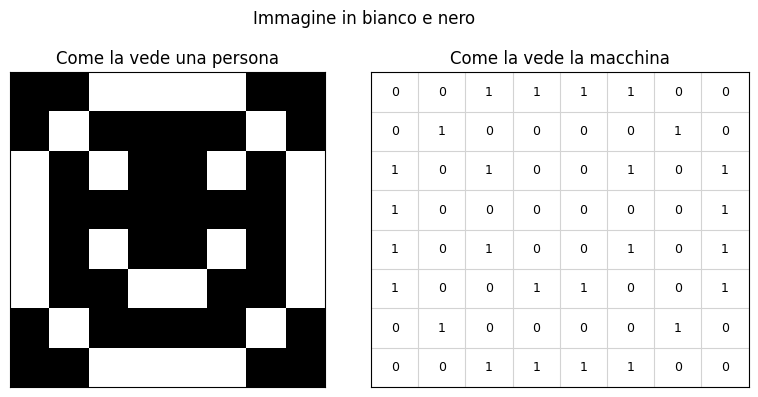

In [22]:
import matplotlib.pyplot as plt
from nlp.images import smiley, show_image

image = smiley()
show_image(image, title="Immagine in bianco e nero")
plt.show()

## Un momento di riflessione

- Quanti bit servono per memorizzare questa immagine? E per una di 1000×1000 pixel?
- Se per trasmettere l'immagine a un'altra persona potessi inviare solo sequenze di 0 e 1, cosa dovreste concordare oltre ai valori dei pixel? (Suggerimento: quante righe? quante colonne? in che ordine leggere i pixel?)
- Che cosa succede se un punto dell'immagine non è né completamente bianco né completamente nero?

## Le scale di grigio

Per rappresentare anche i grigi servono più valori possibili per ogni pixel. Vediamo una sfumatura che va dal nero (0) al bianco (255), rappresentata con un numero diverso di bit per pixel.

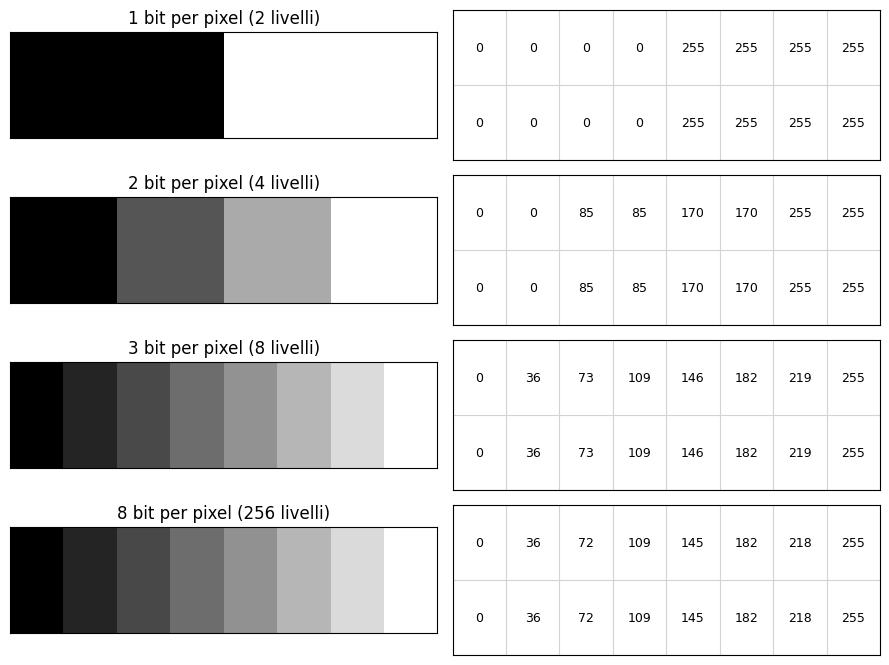

In [23]:
from nlp.images import gradient, show_quantization

show_quantization(gradient(), bits_list=[1, 2, 3, 8])

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

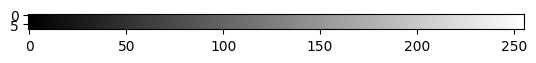

In [24]:
a = np.array(range(0, 256)) 
b = np.array(range(0, 256))
i = np.array([a, b, a, b, a, b, a, b])

print(a)
plt.imshow(i, cmap='gray')

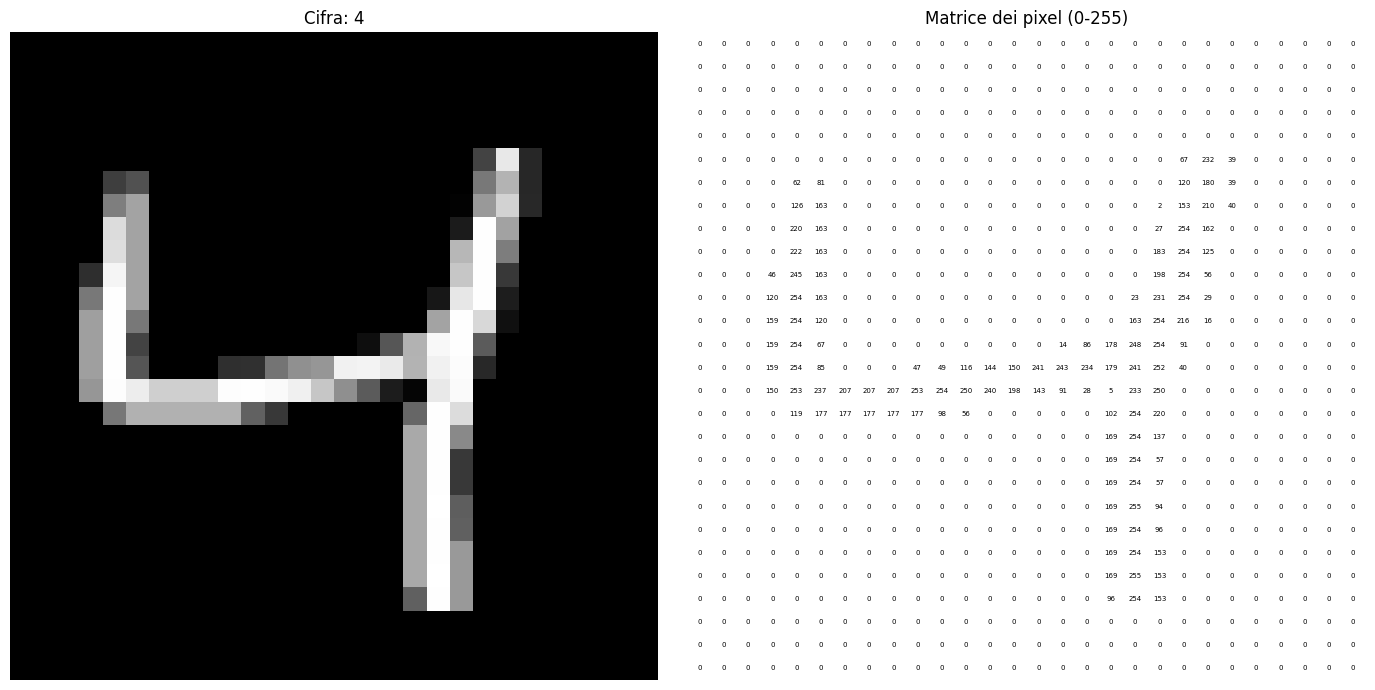

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets

# Carica il dataset MNIST (scarica in ./data se non presente)
train_set = datasets.MNIST(root='./data', train=True, download=True)

# Seleziona un'immagine di esempio
idx = 2
img = np.array(train_set.data[idx])   # array 28x28, valori 0-255
label = train_set.targets[idx].item()

# Crea la figura con due sottoplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Sottoplot 1: immagine originale
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f"Cifra: {label}")
axes[0].axis('off')

# Sottoplot 2: matrice numerica su sfondo bianco fisso
axes[1].set_facecolor('white')
axes[1].set_xlim(-0.5, img.shape[1] - 0.5)
axes[1].set_ylim(img.shape[0] - 0.5, -0.5)  # asse y invertito come in imshow
axes[1].set_title("Matrice dei pixel (0-255)")
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        val = img[i, j]
        axes[1].text(j, i, str(val), ha='center', va='center',
                     color='black', fontsize=5)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Un momento di riflessione

- Quanti livelli di grigio si possono distinguere con 1 bit? E con 2? E con 3? Riesci a prevedere quanti con 8?
- Che relazione c'è tra il numero di bit per pixel e il numero di livelli disponibili? Ti ricorda la formula $L = \lceil \log_B(N) \rceil$ vista all'inizio?
- Con 1 bit la sfumatura si è ridotta a due blocchi netti. Cosa cambia a occhio passando da 3 a 8 bit?
- Perché nella scala a 8 bit il valore massimo è 255 e non 256?

## Il colore

Per rappresentare un colore un solo numero per pixel non basta. Un metodo molto diffuso è descrivere ogni pixel con tre numeri, da 0 a 255, che indicano quanto **rosso** (R), **verde** (G) e **blu** (B) contiene: il sistema **RGB**.

Vediamo una piccola immagine di 4×4 pixel, con i tre numeri di ogni pixel separati nei tre canali.

Forma dei dati: (4, 4, 3)
Pixel in alto a destra (R, G, B): [255 255   0]


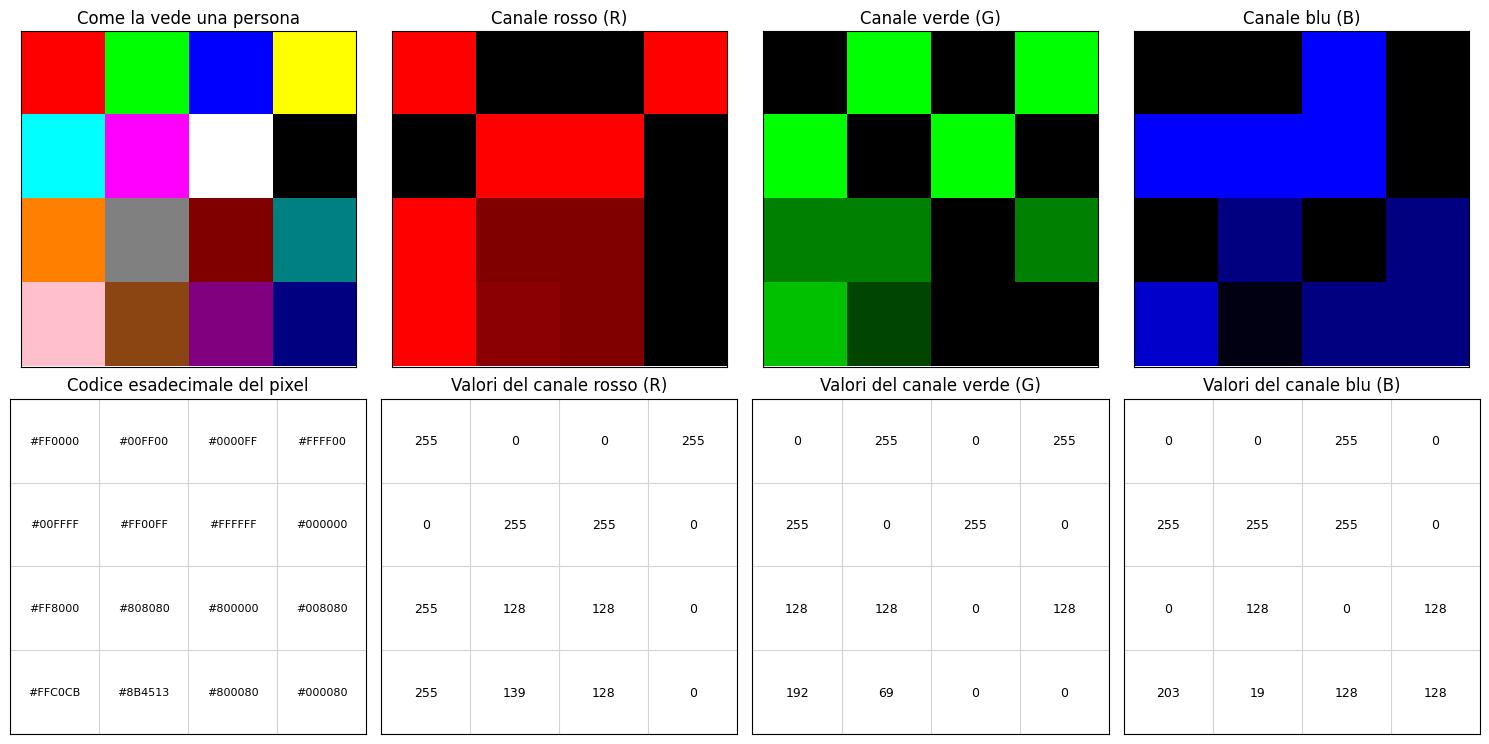

In [26]:
from nlp.images import color_patches, show_channels

color_image = color_patches()

print(f"Forma dei dati: {color_image.shape}")
print(f"Pixel in alto a destra (R, G, B): {color_image[0, 3]}")

show_channels(color_image)

## Un momento di riflessione

- L'immagine che vediamo è piatta, in due dimensioni, ma i dati hanno la forma `(4, 4, 3)`. Da dove viene il 3? Come immagini queste tre matrici, una rispetto all'altra?
- Il pixel in alto a destra è giallo. Che valori hanno i suoi tre canali? Cosa ti dice questo su come si "ottiene" il giallo?
- Quanti bit servono per un pixel a colori, se ogni canale usa 8 bit? Quanti colori diversi si possono rappresentare?
- Perché il codice esadecimale di ogni pixel è fatto di sei cifre? Come si collegano le coppie di cifre ai tre canali?
- Cosa significano i pixel `#000000` e `#FFFFFF`?

## Un'immagine reale

Passiamo a un'immagine vera: un dipinto di Filippo Lippi. Ha centinaia di migliaia di pixel, quindi non possiamo più leggerne i numeri uno per uno, ma la struttura è la stessa dell'esempio precedente: tre matrici sovrapposte, una per canale.

Forma dei dati: (1033, 736, 3)
Pixel: 760,288 (per 3 canali = 2,280,864 numeri)


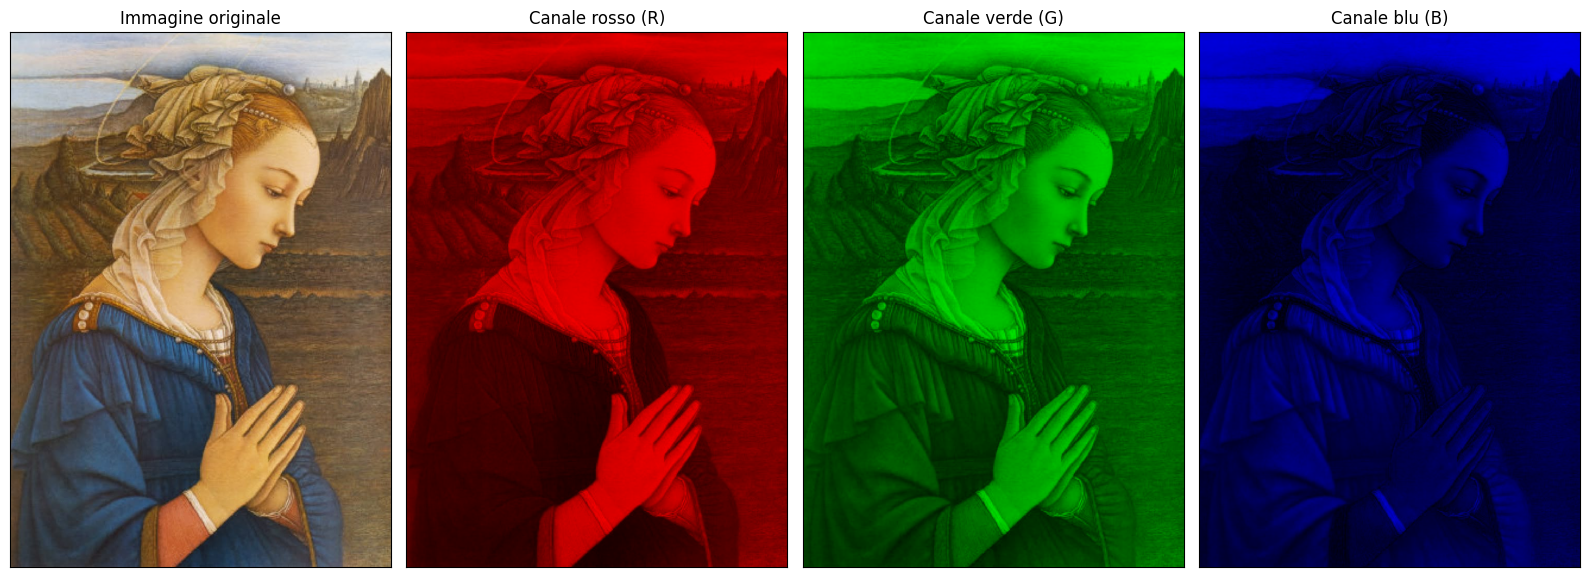

In [27]:
from nlp.images import load_image, show_real_channels

painting = load_image("data/lippi.jpg")

height, width, channels = painting.shape
print(f"Forma dei dati: {painting.shape}")
print(f"Pixel: {height * width:,} (per {channels} canali = {height * width * channels:,} numeri)")

show_real_channels(painting)

## Un momento di riflessione

- Quanti numeri servono per descrivere questa immagine? E quanti byte, se ogni numero occupa 1 byte?
- In quale canale è più luminoso il manto della Madonna? E la pelle del viso e delle mani? Come si spiegano queste differenze?
- Quale canale contiene meno informazione visibile? Perché?
- Se sommassimo di nuovo i tre canali, cosa otterremmo? Ci sarebbe qualche perdita rispetto all'immagine originale?

## La compressione

Il dipinto che abbiamo appena aperto, come matrice di numeri, occupa più di 2 MB. Eppure il file `lippi.jpg` da cui l'abbiamo letto è molto più piccolo. Confrontiamo le due dimensioni.

In [28]:
import os
from nlp.compression import raw_size

matrix_size = raw_size(height, width, channels)
file_size = os.path.getsize("data/lippi.jpg")

print(f"Matrice di numeri in memoria: {matrix_size:,} byte ({matrix_size / 1000:,.0f} kB)")
print(f"File lippi.jpg su disco:      {file_size:,} byte ({file_size / 1000:,.0f} kB)")
print(f"Rapporto: {matrix_size / file_size:.1f} a 1")

Matrice di numeri in memoria: 2,280,864 byte (2,281 kB)
File lippi.jpg su disco:      99,652 byte (100 kB)
Rapporto: 22.9 a 1


Il file è circa 23 volte più piccolo della matrice. Come è possibile? E che cosa perdiamo in cambio?

Salviamo la stessa immagine in formati diversi e misuriamo, per ciascuno, la dimensione del file e l'**errore medio**: di quanto, in media, i valori dei pixel dell'immagine ricostruita differiscono da quelli originali (su una scala da 0 a 255).

In [29]:
from nlp.compression import compare_formats, print_format_table

rows = compare_formats(painting)
print_format_table(rows, original_size=matrix_size)

formato           tipo                   dimensione (kB)  rapporto  errore medio
BMP               senza compressione             2,280.9      1.0x          0.00
PNG               senza perdita                    918.6      2.5x          0.00
WebP lossless     senza perdita                    649.8      3.5x          0.00
JPEG qualità 95   con perdita                      186.1     12.3x          0.37
JPEG qualità 75   con perdita                       91.2     25.0x          1.54
JPEG qualità 50   con perdita                       63.5     35.9x          2.56
JPEG qualità 10   con perdita                       22.5    101.3x          6.72
WebP qualità 75   con perdita                       54.0     42.2x          2.62


Alcune caratteristiche dei principali formati:

| Formato | Compressione | Colori per canale | Trasparenza | Usi tipici |
|---|---|---|---|---|
| BMP | nessuna | 8 bit | no | archiviazione grezza, uso didattico |
| GIF | senza perdita | palette di soli 256 colori | sì (on/off) | grafica semplice, animazioni |
| PNG | senza perdita | 8 o 16 bit | sì | grafica, schermate, immagini da conservare |
| JPEG | con perdita | 8 bit | no | fotografie, immagini per il web |
| WebP | con o senza perdita | 8 bit | sì | immagini per il web |
| TIFF | nessuna o senza perdita | 8 o 16 bit | sì | scansioni e archiviazione professionale |

E quanto pesano, senza compressione, le immagini con le risoluzioni più comuni?

In [30]:
from nlp.compression import print_standard_sizes

print_standard_sizes()

standard                                 pixel   dimensione non compressa (MB)
VGA (640x480)                          307,200                             0.9
HD (1280x720)                          921,600                             2.8
Full HD (1920x1080)                  2,073,600                             6.2
4K (3840x2160)                       8,294,400                            24.9
Fotocamera 12 Mpixel (4000x3000)    12,000,000                            36.0


Il JPEG "perde" informazione: vediamo cosa succede al volto della Madonna, ingrandito, a qualità sempre più bassa.

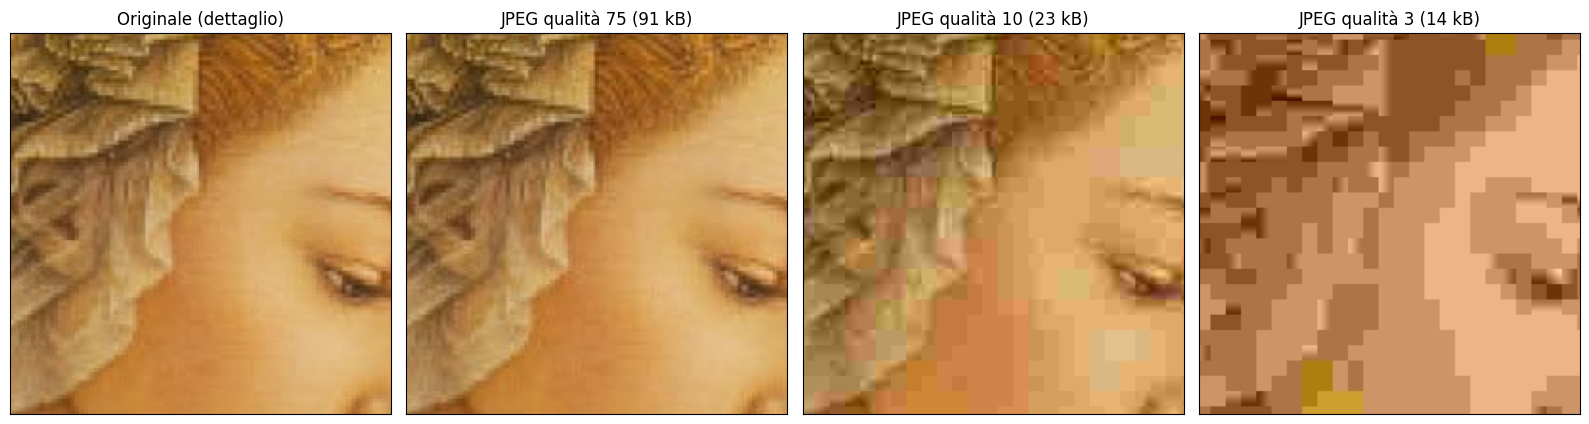

In [31]:
from nlp.compression import show_quality_comparison

show_quality_comparison(painting, qualities=[75, 10, 3], box=(180, 380, 330, 530))

## Un momento di riflessione

- Perché il PNG riesce a ridurre l'immagine (di circa 2,5 volte) senza alcun errore? Cosa c'è di "ripetitivo" o prevedibile in un'immagine? Ti ricorda qualcosa della ridondanza del linguaggio e dell'entropia?
- Il JPEG a qualità 75 riduce l'immagine di 25 volte con un errore medio di circa 1,5 livelli su 255. Quanto pensi che si veda a occhio? Perché possiamo permetterci di "perdere" quell'informazione?
- Cosa succede al dettaglio a qualità 10 e a qualità 3? Cosa notano gli occhi, e che forma hanno gli errori?
- Se dovessi conservare per sempre la scansione di un manoscritto, che formato sceglieresti? E per metterne una copia su un sito web? Perché?
- Cosa succederebbe se salvassi più volte di seguito la stessa immagine in JPEG, ogni volta a qualità bassa?

## Come comprimono i diversi formati

Ogni formato usa una strategia diversa. Le strategie **senza perdita** sfruttano la ridondanza dei dati (valori ripetuti o prevedibili, come nel caso dell'entropia); quelle **con perdita** scartano anche informazione poco percepibile. Vediamo un piccolo esempio per ciascun formato, dal più semplice al più sofisticato.

**BMP: nessuna compressione.** Il file contiene una breve intestazione (54 byte) seguita dai pixel uno dopo l'altro, 3 byte ciascuno (più un eventuale riempimento a fine riga). La dimensione è quindi prevedibile: larghezza × altezza × 3 + 54.

In [32]:
from nlp.compression import encode

print(f"Dimensione prevista: {raw_size(height, width) + 54:,} byte")
print(f"Dimensione reale:    {len(encode(painting, 'BMP')):,} byte")

Dimensione prevista: 2,280,918 byte
Dimensione reale:    2,280,918 byte


**TIFF: un contenitore con compressione opzionale.** Può non comprimere affatto (come nel nostro confronto) oppure usare schemi diversi. Il più semplice è la **codifica a lunghezze di corsa** (*run-length encoding*): una sequenza di valori uguali consecutivi viene sostituita dal valore e da quante volte si ripete. Funziona bene dove ci sono ampie zone uniformi; su una fotografia, dove i valori cambiano di continuo, quasi non ci sono ripetizioni esatte.

In [33]:
from nlp.compression import rle_encode

row = [0] * 12 + [255] * 3 + [0] * 9
runs = rle_encode(row)

print(f"Riga di {len(row)} pixel: {row}")
print(f"Codificata in {len(runs)} coppie (valore, ripetizioni): {runs}")

Riga di 24 pixel: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 255, 255, 255, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Codificata in 3 coppie (valore, ripetizioni): [(0, 12), (255, 3), (0, 9)]


**GIF: palette e dizionario.** Combina due idee. La prima: invece di 3 byte per pixel si sceglie una tavolozza (*palette*) di al massimo 256 colori e ogni pixel memorizza solo l'indice del suo colore, cioè 1 byte. La seconda: la sequenza di indici viene compressa con l'algoritmo **LZW**, che costruisce man mano un dizionario di sequenze già viste e le sostituisce con un solo codice. Ridurre a 256 colori una fotografia che ne contiene decine di migliaia comporta però una perdita.

In [34]:
import numpy as np
from nlp.compression import reduce_palette, lzw_encode

indices, palette = reduce_palette(painting, colors=256)
distinct_colors = len(np.unique(painting.reshape(-1, 3), axis=0))
print(f"Colori distinti nel dipinto: {distinct_colors:,}")
print(f"Colori nella palette: {len(palette)}")
print(f"Byte per il colore dei pixel: {painting.nbytes:,} -> {indices.nbytes:,}")

text = "TOBEORNOTTOBEORTOBEORNOT"
codes, learned = lzw_encode(text)
print(f"\nLZW su una stringa: {len(text)} caratteri -> {len(codes)} codici")
print(f"Codici: {codes}")
print(f"Prime sequenze imparate: {dict(list(learned.items())[:6])}")

Colori distinti nel dipinto: 94,320
Colori nella palette: 256
Byte per il colore dei pixel: 2,280,864 -> 760,288

LZW su una stringa: 24 caratteri -> 16 codici
Codici: [84, 79, 66, 69, 79, 82, 78, 79, 84, 256, 258, 260, 265, 259, 261, 263]
Prime sequenze imparate: {256: 'TO', 257: 'OB', 258: 'BE', 259: 'EO', 260: 'OR', 261: 'RN'}


**PNG: predizione e DEFLATE.** Prima, ogni pixel viene sostituito dalla differenza rispetto al pixel vicino (un *filtro*): dove i colori cambiano lentamente, le differenze sono numeri piccoli e ripetitivi. Poi i dati filtrati vengono compressi con DEFLATE, lo stesso algoritmo dei file zip, che combina un dizionario di sequenze già viste (come LZW) con codici più corti per i valori più frequenti. Il procedimento è interamente reversibile: nessuna perdita.

In [35]:
from nlp.compression import sub_filter, deflate_size

gradient_row = np.arange(100, 200, dtype=np.uint8).reshape(1, -1)
print(f"Gradiente di 100 valori con DEFLATE: {deflate_size(gradient_row)} byte")
print(f"Lo stesso, dopo il filtro (differenze): {deflate_size(sub_filter(gradient_row))} byte")

print(f"\nDipinto senza filtro: {deflate_size(painting):,} byte")
print(f"Dipinto con filtro:   {deflate_size(sub_filter(painting)):,} byte")

Gradiente di 100 valori con DEFLATE: 111 byte
Lo stesso, dopo il filtro (differenze): 12 byte

Dipinto senza filtro: 1,544,327 byte
Dipinto con filtro:   1,012,867 byte


**JPEG: trasformata e quantizzazione.** L'immagine è divisa in blocchi di 8×8 pixel (dopo aver separato luminosità e colore e ridotto la risoluzione del colore, a cui l'occhio è meno sensibile). Ogni blocco viene trasformato con la **trasformata discreta del coseno** (DCT), che lo descrive non come 64 pixel ma come somma di 64 "schemi" a frequenza crescente: il primo coefficiente è la luminosità media del blocco, gli altri sono dettagli via via più fini. I coefficienti vengono poi divisi per una tabella di numeri (più grandi per i dettagli fini) e arrotondati: è qui che avviene la perdita. Quasi tutti i coefficienti diventano 0, e una lunga fila di zeri si comprime moltissimo. Il parametro "qualità" regola la grandezza dei divisori.

Guardiamo un blocco di 8×8 pixel in scala di grigio, sulla guancia della Madonna.

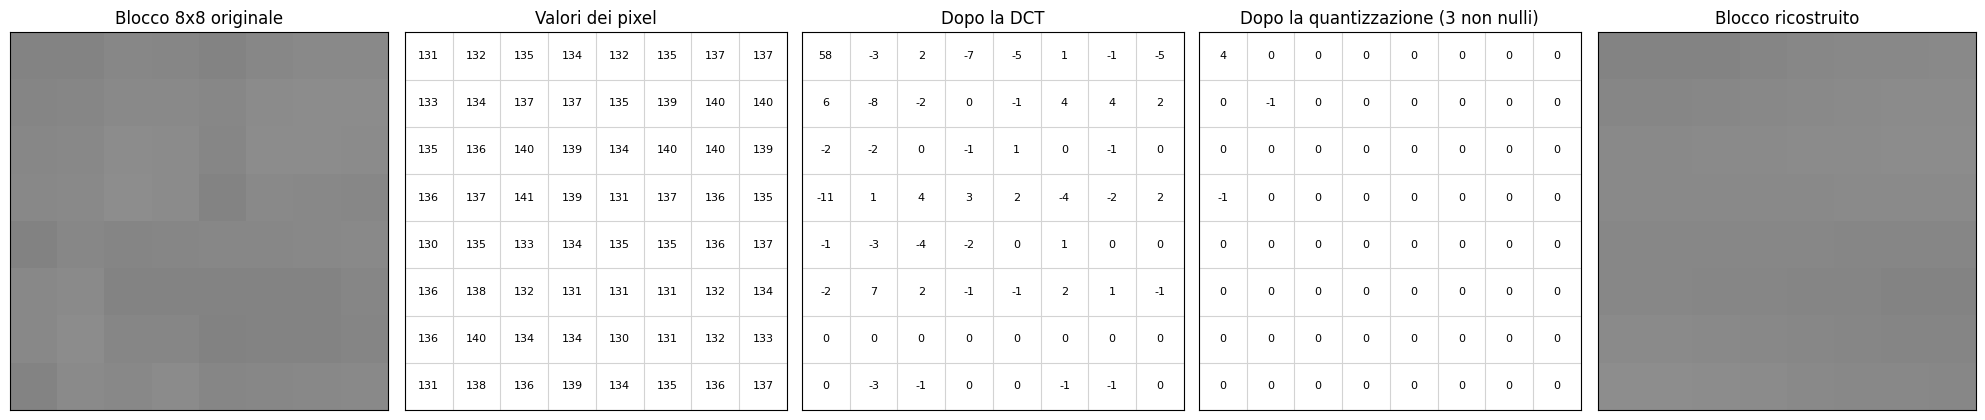

In [36]:
from nlp.compression import grayscale, show_jpeg_block

show_jpeg_block(grayscale(painting), top=300, left=420)

**WebP: predizione più raffinata.** Riprende e combina le idee precedenti. Nella versione senza perdita ogni pixel viene predetto a partire dai vicini già noti e si memorizza solo l'errore di predizione (il *residuo*); i residui sono poi codificati con codici di lunghezza variabile e con riferimenti a sequenze già viste. Nella versione con perdita la predizione lavora su blocchi, e i residui passano per una trasformata e una quantizzazione simili a quelle del JPEG.

Perché la predizione aiuta? Perché rende i valori più prevedibili, cioè ne abbassa l'entropia. Proviamo a misurarlo sul dipinto in scala di grigio, predicendo ogni pixel dal suo vicino di sinistra.

In [37]:
from nlp.compression import value_entropy

gray = grayscale(painting)
residuals = sub_filter(gray)

print(f"Entropia dei pixel:   {value_entropy(gray):.2f} bit per pixel")
print(f"Entropia dei residui: {value_entropy(residuals):.2f} bit per pixel")

Entropia dei pixel:   7.22 bit per pixel
Entropia dei residui: 4.07 bit per pixel


## Un momento di riflessione

- Perché la codifica a lunghezze di corsa funziona bene su un'icona con grandi aree uniformi ma quasi non aiuta su una fotografia?
- Il GIF riduce i colori del dipinto da decine di migliaia a 256: è una compressione con o senza perdita? In quali casi è comunque una buona idea?
- Perché calcolare le differenze tra pixel vicini aiuta a comprimere? Cosa è successo all'entropia?
- Nel blocco JPEG, dove avviene esattamente la perdita di informazione? Cosa significa che quasi tutti i coefficienti diventano zero?
- Quale di queste strategie ti sembra più adatta a comprimere un testo? E la scansione di una pagina con testo nero su sfondo bianco?

## Manipolare le immagini

Se un'immagine è una matrice di numeri, modificare l'immagine significa modificare i numeri. Costruiamo un piccolo strumento per farlo: si sceglie un **rettangolo** con le coordinate in pixel (riga *y* e colonna *x*, con l'origine in alto a sinistra), uno o più **canali**, una **trasformazione** e la sua **intensità** (0 = nessun effetto, 1 = effetto pieno).

Cominciamo con la trasformazione più semplice possibile: sostituire i numeri della regione con numeri casuali. Qui l'abbiamo applicata al solo canale rosso di una regione che copre il volto.

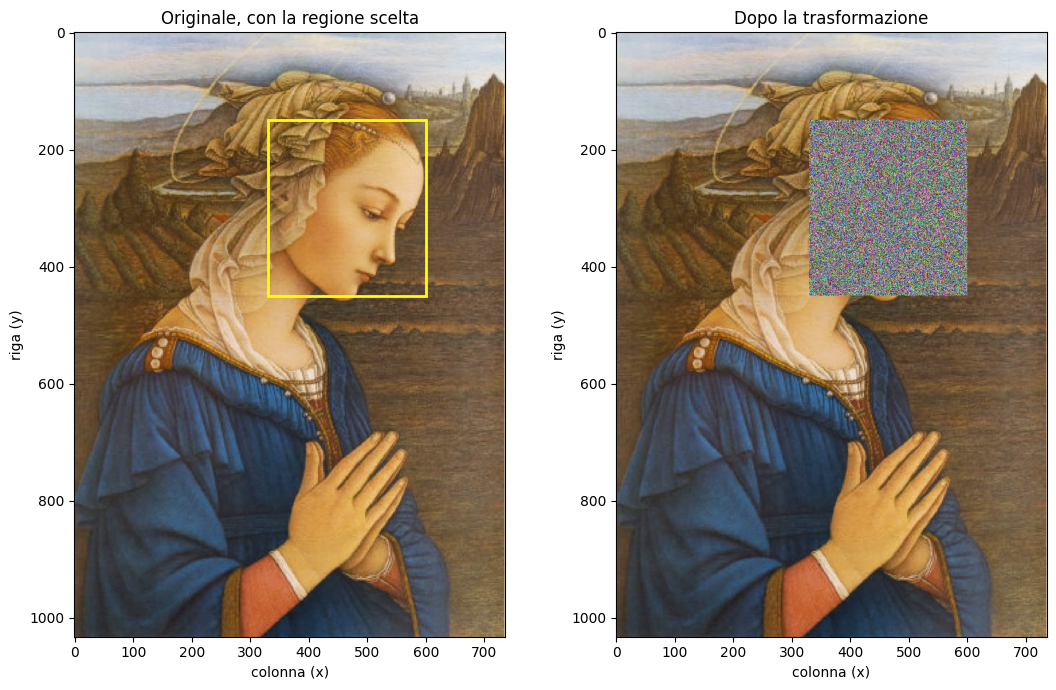

In [50]:
from nlp.transforms import apply_transformation, draw_comparison, random_noise

rows, cols = (150, 450), (330, 600)
edited = apply_transformation(painting, random_noise, rows, cols, channels=["R", "G", "B"])
draw_comparison(painting, edited, rows, cols)

Ora provate voi con lo strumento interattivo: scegliete la regione con i cursori, i canali con le caselle e l'intensità dell'effetto.

In [39]:
from nlp.transforms import interactive_editor, RANDOM_TRANSFORMATIONS

interactive_editor(painting, RANDOM_TRANSFORMATIONS)

## Un momento di riflessione

- Cosa cambia se il rumore viene applicato solo al canale rosso? E solo al blu? E a tutti e tre i canali insieme?
- Perché il volto, con il rumore sul solo canale rosso, cambia *colore* invece di diventare semplicemente "sporco"?
- Con intensità bassa la regione è ancora riconoscibile. Cosa vuol dire, in termini di numeri, mescolare l'originale con il rumore?
- Il resto dell'immagine è cambiato? Cosa ti dice questo sul fatto che ogni pixel è un numero indipendente dagli altri?
- Quanti numeri hai modificato? Cosa succederebbe a un file di immagine se qualche numero venisse alterato per errore?

## I filtri

Una trasformazione più utile del rumore agisce sui numeri seguendo una regola precisa: si chiama **filtro**. Ci sono due famiglie.

- **Operazioni puntuali**: il nuovo valore di un pixel dipende solo dal suo vecchio valore.
  - *Negativo*: $255 - x$
  - *Più chiaro* / *più scuro*: $x + 60$ / $x - 60$
  - *Soglia*: 255 se $x \geq 128$, altrimenti 0

  Il risultato viene sempre riportato nell'intervallo 0-255, l'unico rappresentabile con 8 bit.
- **Operazioni di vicinato**: il nuovo valore dipende anche dai pixel vicini. Le vedremo dopo.

Vediamo prima come agiscono su una piccola matrice 8×8 in scala di grigio: un quadrato chiaro (200) su uno sfondo scuro (50).

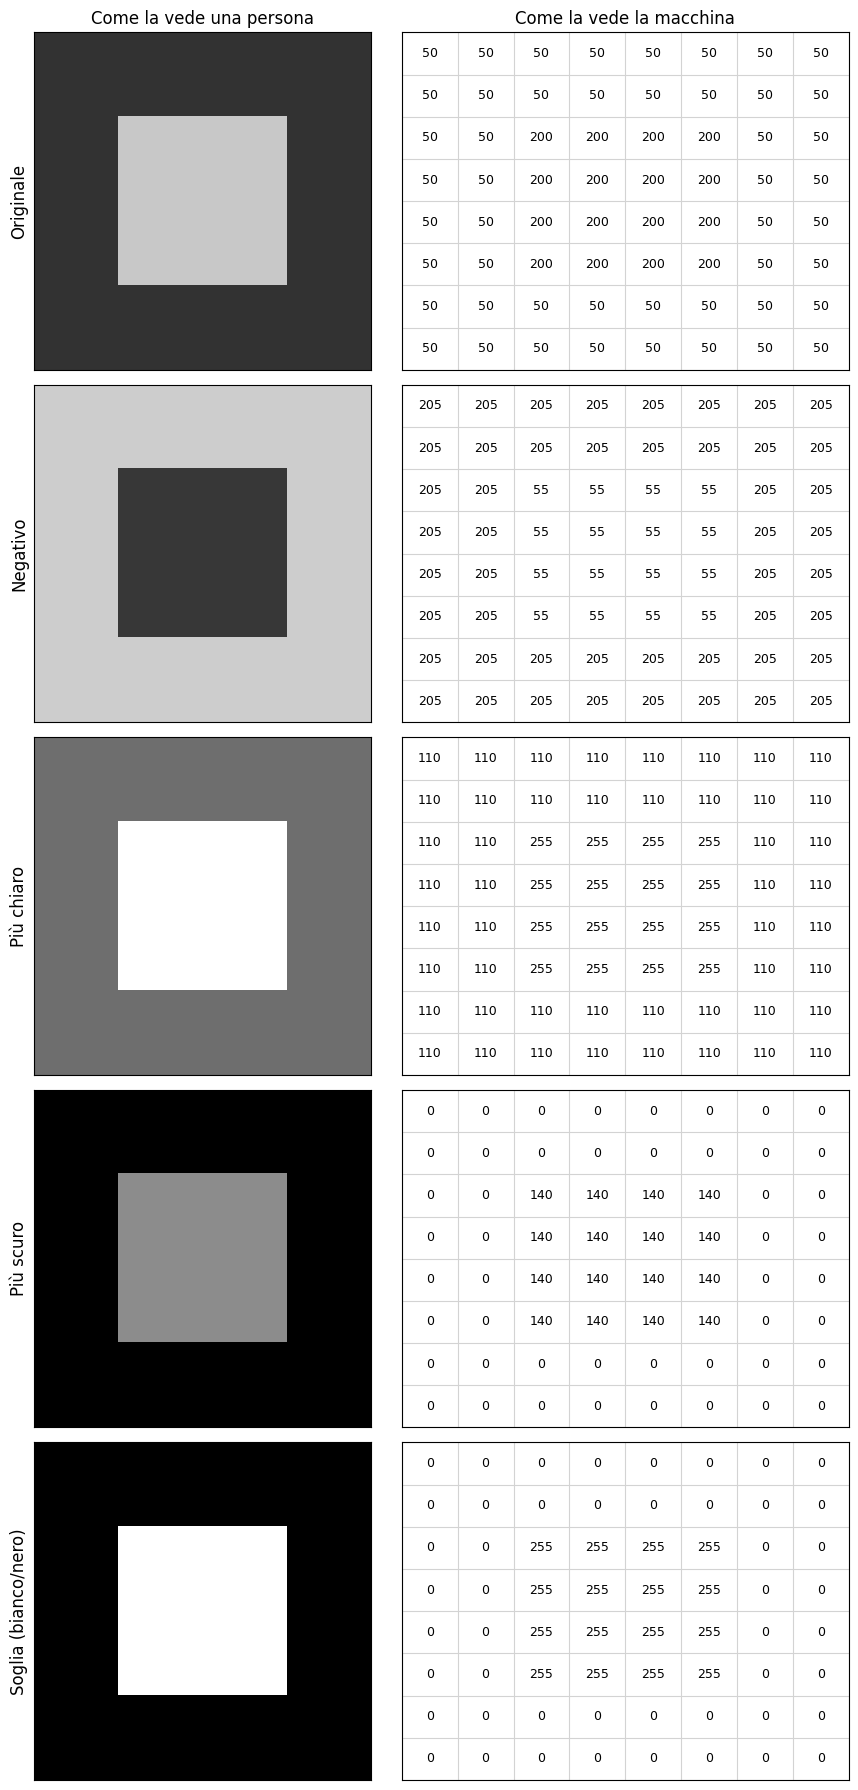

In [51]:
from nlp.transforms import small_matrix, show_filter_examples, POINT_FILTERS

matrix = small_matrix()
show_filter_examples(matrix, POINT_FILTERS)

Le **operazioni di vicinato** usano una piccola matrice detta **nucleo** (*kernel*). Per ogni pixel si sovrappone il nucleo al suo vicinato 3×3, si moltiplicano i numeri elemento per elemento e si sommano i prodotti: il risultato è il nuovo valore del pixel. Ripetendo l'operazione per ogni pixel si scorre il nucleo su tutta l'immagine (l'operazione si chiama **convoluzione**).

Vediamo il calcolo per un singolo pixel con il nucleo della sfocatura, che sostituisce ogni pixel con la media dei nove valori del suo vicinato.

In [41]:
from nlp.transforms import explain_kernel_at, KERNELS

explain_kernel_at(matrix, KERNELS["Sfocatura"], row=2, col=3)

Vicinato 3x3 attorno al pixel (2, 3):
[[ 50  50  50]
 [200 200 200]
 [200 200 200]]

Nucleo (kernel):
[[0.11 0.11 0.11]
 [0.11 0.11 0.11]
 [0.11 0.11 0.11]]

Prodotti elemento per elemento:
[[ 5.6  5.6  5.6]
 [22.2 22.2 22.2]
 [22.2 22.2 22.2]]

Somma dei prodotti = nuovo valore del pixel: 150.0


Cambiando i numeri del nucleo si ottengono effetti diversi. Quattro nuclei molto usati sono: **sfocatura** (media del vicinato), **nitidezza** (accentua la differenza tra un pixel e i suoi vicini), **bordi** (evidenzia dove i valori cambiano bruscamente) e **rilievo** (dà un effetto di luce radente). Vediamoli sulla stessa matrice.

Sfocatura:
[[0.11 0.11 0.11]
 [0.11 0.11 0.11]
 [0.11 0.11 0.11]]

Nitidezza:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]

Bordi:
[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]

Rilievo:
[[-2 -1  0]
 [-1  1  1]
 [ 0  1  2]]



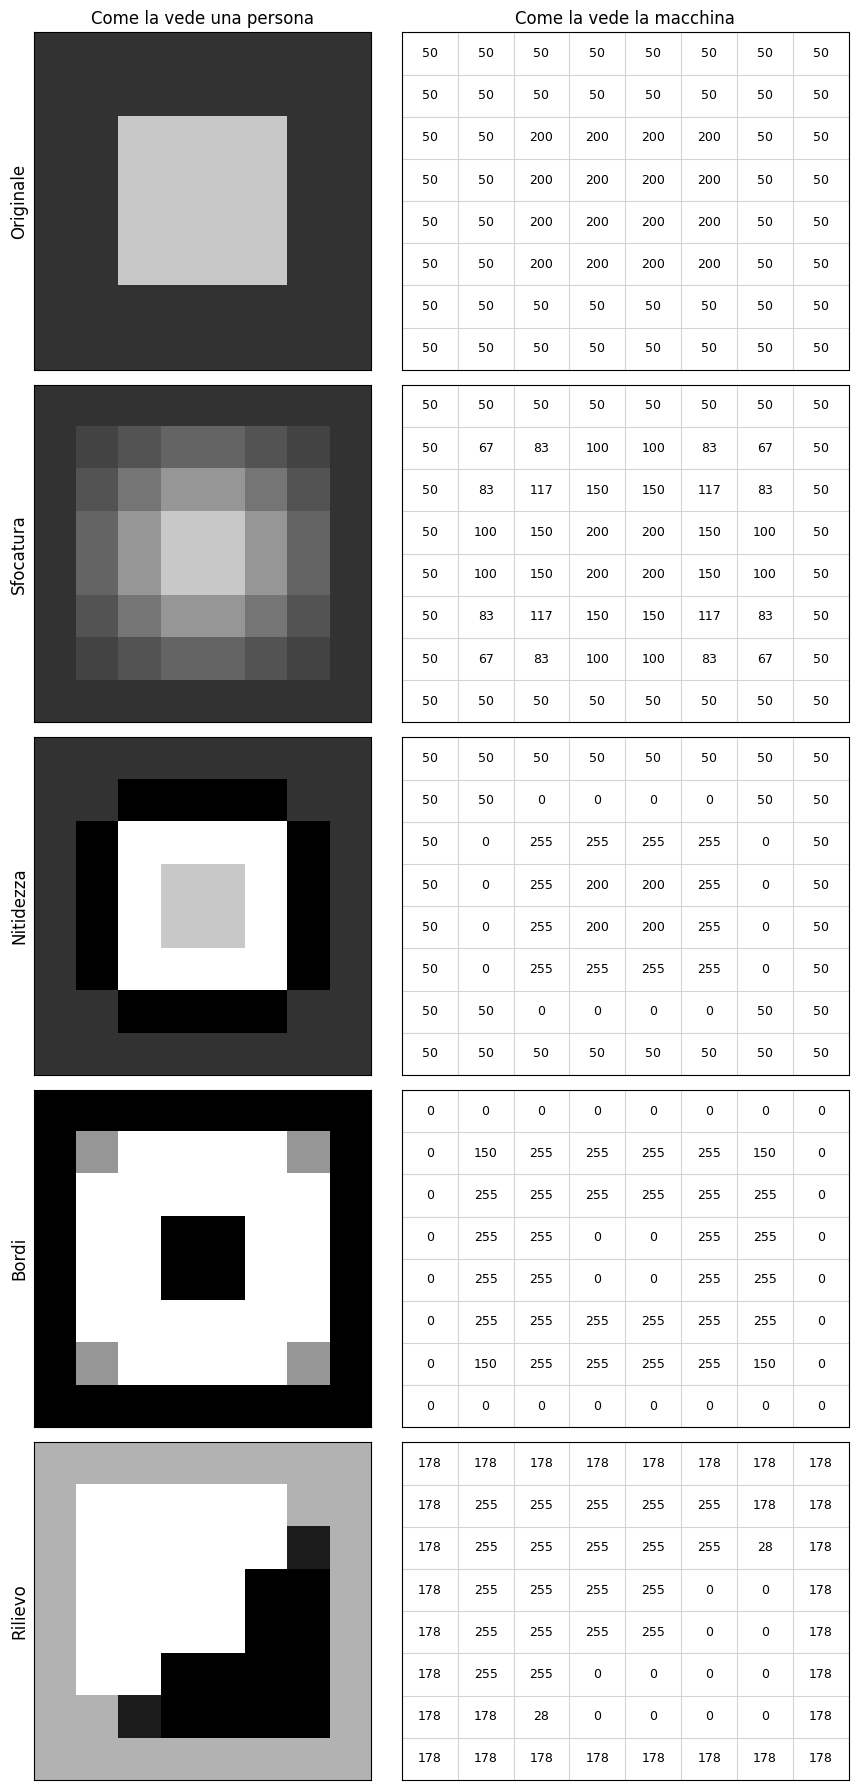

In [52]:
import numpy as np
from nlp.transforms import KERNEL_FILTERS

for name, kernel in KERNELS.items():
    print(f"{name}:\n{np.round(kernel, 2)}\n")

show_filter_examples(matrix, KERNEL_FILTERS)

## Un momento di riflessione

- Applicando due volte di seguito il negativo, cosa ottieni? E applicando due volte la soglia? Quale dei due filtri puntuali è reversibile e quale no?
- Nella matrice sfocata, cosa succede ai pixel sul bordo del quadrato? E ai pixel lontani dal bordo?
- I numeri del nucleo dei bordi sommano a 0. Cosa succede, per questo, nelle zone in cui tutti i pixel hanno lo stesso valore? E dove i valori cambiano?
- I numeri del nucleo della sfocatura sommano a 1 (nove volte 1/9). Perché è importante, se non vogliamo cambiare la luminosità media dell'immagine?
- In alcune celle il risultato sarebbe minore di 0 o maggiore di 255. Cosa abbiamo fatto? Cosa sarebbe successo altrimenti?

## I filtri sull'immagine reale

Applichiamo gli stessi filtri all'intero dipinto, e poi rendiamoli disponibili nello strumento interattivo, dove possiamo scegliere regione, canali e intensità (provate, ad esempio, la sfocatura solo sul volto o il negativo solo sul canale blu).

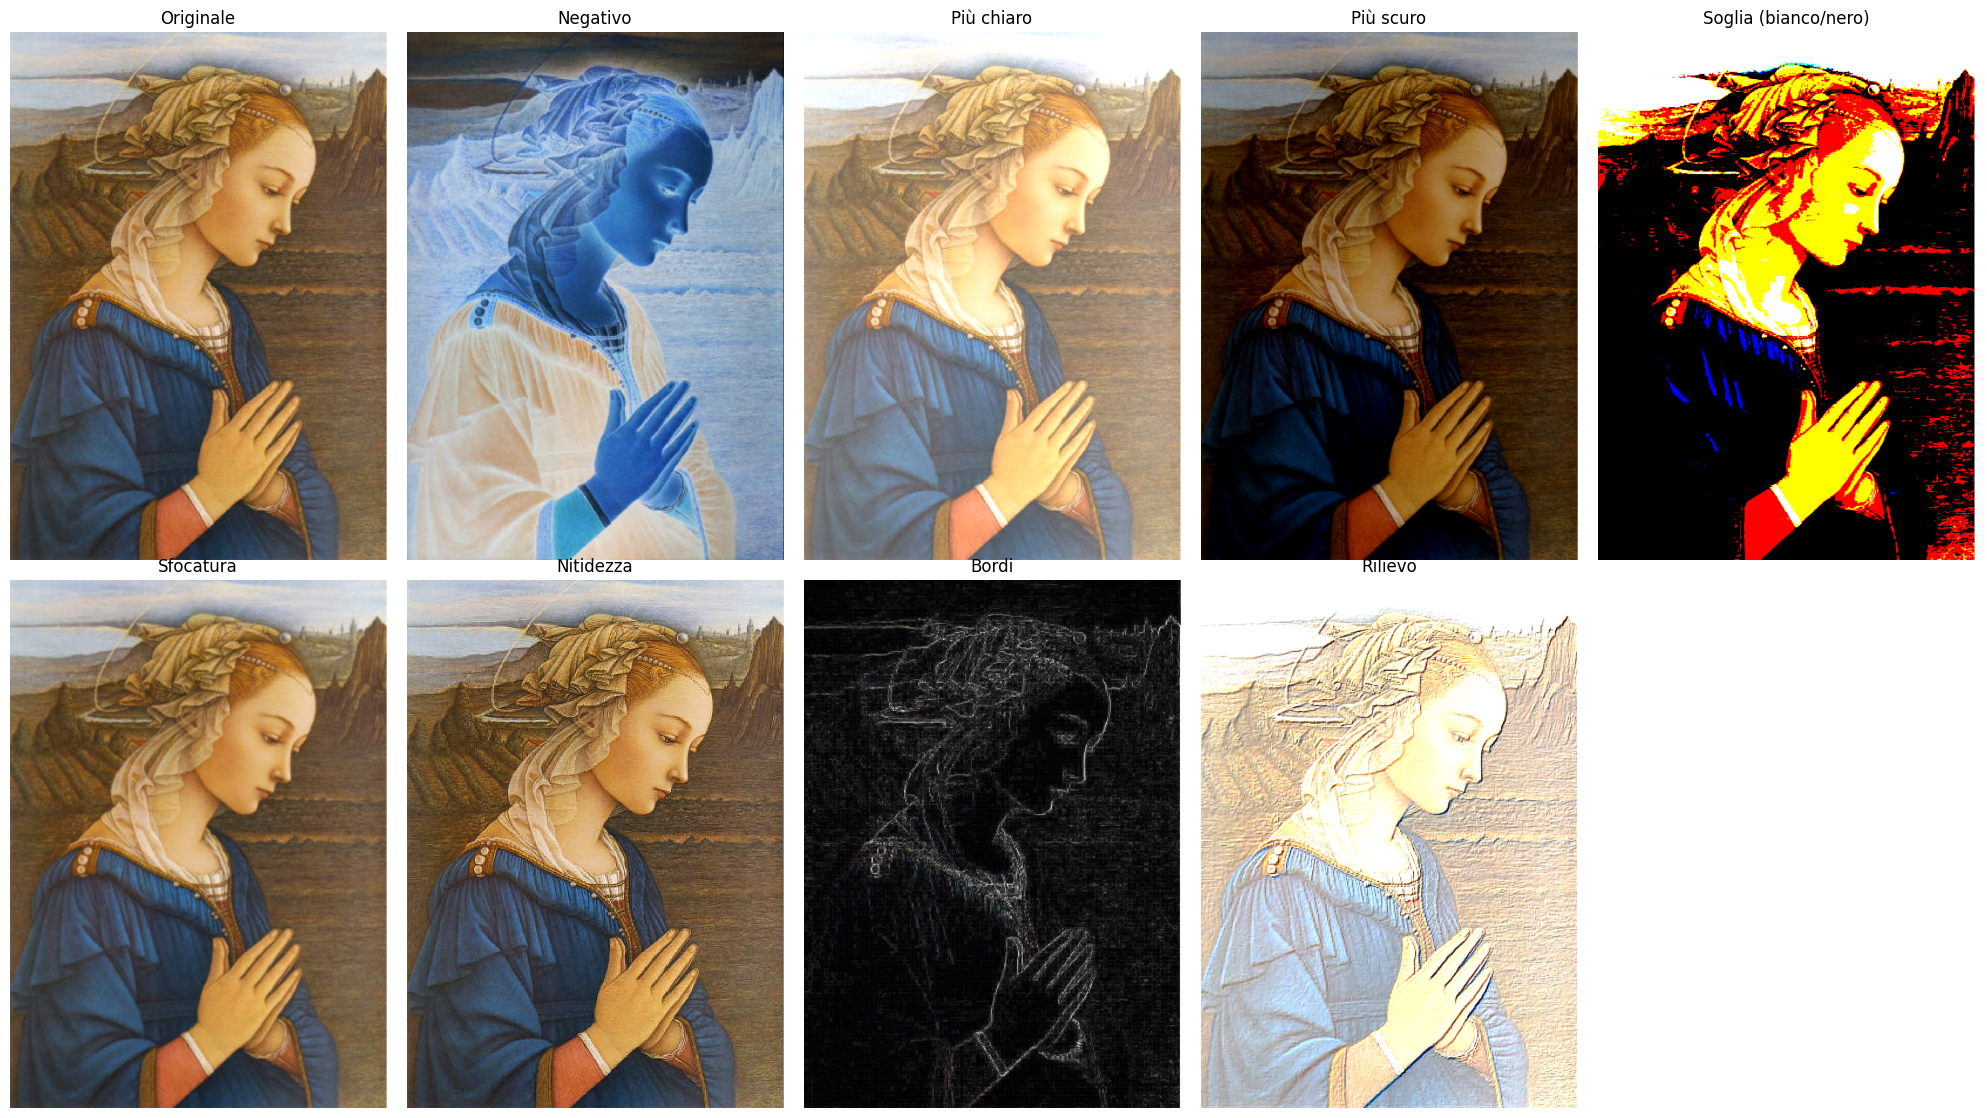

In [43]:
from nlp.transforms import show_filter_gallery

show_filter_gallery(painting, {**POINT_FILTERS, **KERNEL_FILTERS})

In [44]:
from nlp.transforms import ALL_TRANSFORMATIONS

interactive_editor(painting, ALL_TRANSFORMATIONS)

## Un momento di riflessione

- Che differenza noti tra sfocatura e nitidezza su un dettaglio piccolo (per esempio un occhio) e su una regione ampia?
- Con il filtro dei bordi la maggior parte dell'immagine diventa nera. Cosa viene evidenziato e cosa sparisce? Cosa succede al colore?
- Applica il negativo solo al canale blu: come cambiano i colori del manto e della pelle? Perché?
- Applica la sfocatura solo al canale rosso e poi solo al verde. Riesci a vedere la differenza? Cosa ti suggerisce sulla nostra sensibilità ai singoli canali?
- Tra i filtri provati, quali sono reversibili (potresti riottenere l'originale) e quali distruggono informazione?
- La quantizzazione del JPEG vista prima è una manipolazione dei numeri: a quale famiglia di trasformazioni la avvicineresti? Perché è "con perdita"?

## Il suono

Il suono è una variazione della pressione dell'aria nel tempo. Un microfono la trasforma in un segnale elettrico continuo, che per diventare una sequenza di numeri deve essere **campionato**: se ne misura il valore a intervalli regolari, un certo numero di volte al secondo (la *frequenza di campionamento*, misurata in hertz).

Come per le immagini, dove la griglia di pixel discretizzava lo spazio, qui i campioni discretizzano il tempo. Campioniamo una nota di 440 Hz (il *la* di riferimento) con frequenze di campionamento diverse.

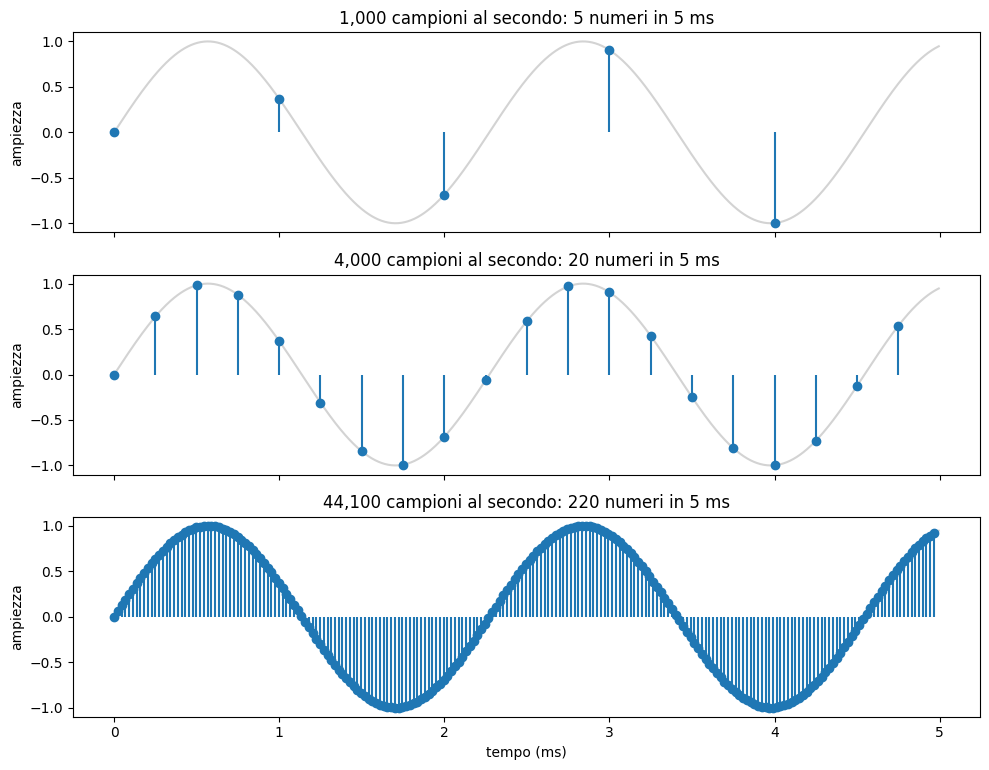

In [45]:
from nlp.audio import show_sampling

show_sampling(440, rates=[1000, 4000, 44100])

Ogni campione, poi, deve essere scritto come un numero con un numero finito di bit: si **quantizza**, arrotondando il valore a uno dei $2^b$ livelli disponibili, dove $b$ è il numero di bit per campione. È lo stesso principio dei livelli di grigio di un pixel. Guardiamo cosa succede con pochi bit, e come appaiono i numeri veri.

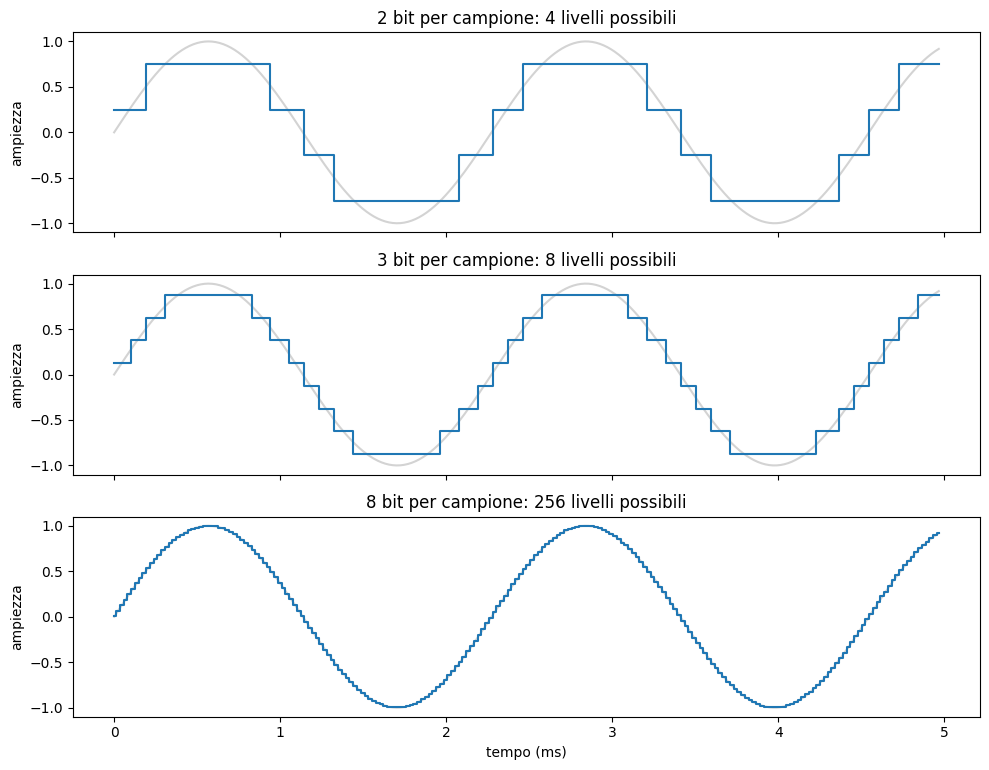

I primi 8 campioni (8000 al secondo) codificati a 16 bit, cioè numeri da 0 a 65535:
[32768 44006 53915 61324 65356 65535 61840 54707]


In [46]:
from nlp.audio import show_bit_depth, tone, quantize_audio

show_bit_depth(440, bits_list=[2, 3, 8])

samples = tone(440, duration=0.001, rate=8000)
print(f"I primi {len(samples)} campioni (8000 al secondo) codificati a 16 bit, cioè numeri da 0 a 65535:")
print(quantize_audio(samples, 16))

Ascoltiamo la stessa nota (con qualche armonica, per renderla più ricca) con tre combinazioni diverse: qualità da CD, pochi campioni al secondo, pochi bit per campione.

In [53]:
from IPython.display import Audio, display
from nlp.audio import note

for rate, bits in [(44100, 16), (4000, 16), (44100, 3)]:
    print(f"{rate:,} campioni al secondo, {bits} bit per campione")
    display(Audio(note(rate, bits), rate=rate))

44,100 campioni al secondo, 16 bit per campione


4,000 campioni al secondo, 16 bit per campione


44,100 campioni al secondo, 3 bit per campione


Quanto pesa un brano non compresso? Basta moltiplicare: campioni al secondo × byte per campione × numero di canali (due nello stereo) × durata. Confrontiamo tre formati per un brano di 3 minuti, e con un MP3 comune.

Anche per il suono esistono formati **senza perdita** (come FLAC, che sfrutta la ridondanza del segnale, in modo analogo al PNG) e formati **con perdita** (come MP3), che eliminano le componenti del suono che l'orecchio percepisce meno, come il JPEG fa con i dettagli fini di un'immagine.

In [48]:
from nlp.audio import print_audio_sizes

print_audio_sizes(seconds=180)

formato                                byte al secondo     3 minuti (MB)
Telefono (8 kHz, 8 bit, mono)                    8,000               1.4
CD (44,1 kHz, 16 bit, stereo)                  176,400              31.8
Studio (96 kHz, 24 bit, stereo)                576,000             103.7

Un MP3 a 128 kbit/s: 16,000 byte al secondo, 2.9 MB (circa 11 volte meno del CD)


## Un momento di riflessione

- Con 1.000 campioni al secondo, la nota di 440 Hz è ancora riconoscibile? Cosa serve, secondo te, perché un'onda si possa ricostruire dai suoi campioni?
- Nell'ascolto, come suonano i campioni troppo rari (4.000 al secondo)? E i pochi bit per campione (3 bit)? Sono due difetti dello stesso tipo?
- Quali parallelismi trovi tra campionamento e quantizzazione del suono e pixel e livelli di grigio delle immagini?
- Perché un CD usa 44.100 campioni al secondo? (Suggerimento: l'orecchio umano sente fino a circa 20.000 Hz.)
- Un brano di 3 minuti da CD pesa circa 32 MB e lo stesso brano in MP3 circa 3 MB. Cosa si è perso, e perché quasi nessuno se ne accorge?